  # Opdracht 2: Imports en Data Laden

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Lees de dataset in
df = pd.read_csv('AmesHousing.csv')



  # Opdracht 3: Data Schoonmaken en Feature Engineering

In [8]:
# Verwijder extreme uitschieters
df = df[df['Gr Liv Area'] < 4000].copy()

target = 'SalePrice'

features = [
    'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood'
]

df_subset = df[features + [target]].copy()

# Vul ontbrekende numerieke waarden op met 0 (bijv. geen kelder of geen garage)
df_subset.fillna(0, inplace=True)



,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,SalePrice
0,6,1656,1080.0,31770,1960,1,3,NAmes,215000
1,5,896,882.0,11622,1961,1,2,NAmes,105000
2,6,1329,1329.0,14267,1958,1,3,NAmes,172000
3,7,2110,2110.0,11160,1968,2,3,NAmes,244000
4,5,1629,928.0,13830,1997,2,3,Gilbert,189900
...,...,...,...,...,...,...,...,...,...
2925,6,1003,1003.0,7937,1984,1,3,Mitchel,142500
2926,5,902,864.0,8885,1983,1,2,Mitchel,131000
2927,5,970,912.0,10441,1992,1,3,Mitchel,132000
2928,5,1389,1389.0,10010,1974,1,2,Mitchel,170000


  # Opdracht 4: Data Voorbereiding

In [9]:
# One-hot encode de categorische features
X = pd.get_dummies(df_subset[features], drop_first=True)

# Log-transformatie op de target variabele (SalePrice)
# np.log1p berekent log(1 + x) en voorkomt problemen met nullen
y = np.log1p(df_subset[target])

# Splits de dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=341476)

# Scaling (Cruciaal voor SGDRegressor)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data: {X_train_scaled.shape[0]} huizen")
print(f"Test data: {X_test_scaled.shape[0]} huizen")


Training data: 2340 huizen
Test data: 585 huizen


  # Opdracht 5: Model Training

In [10]:
# Maak het model aan
model = SGDRegressor(
    loss='squared_error',
    penalty='l2',
    alpha=0.01,
    eta0=0.006,
    max_iter=1000,
    random_state=341476
)

# Train het model in één keer
model.fit(X_train_scaled, y_train)

print("Model succesvol getraind!")


Model succesvol getraind!


  # Opdracht 6: Evaluatie

In [11]:
# 1. Voorspel de prijzen (nog in log-formaat)
y_pred_log = model.predict(X_test_scaled)

# 2. Transformeer alles terug naar normale dollars
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)

# 3. Bereken de scores
mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
r2 = r2_score(y_test_dollars, y_pred_dollars)

print(f"R-squared: {r2:.4f}")
print(f"Gemiddelde fout (MAE):  ${mae:,.2f}")
print(f"Kwadratische fout (RMSE): ${rmse:,.2f}")



R-squared: 0.9304
Gemiddelde fout (MAE):  $16,669.62
Kwadratische fout (RMSE): $22,534.73


  # Visualisatie van de resultaten

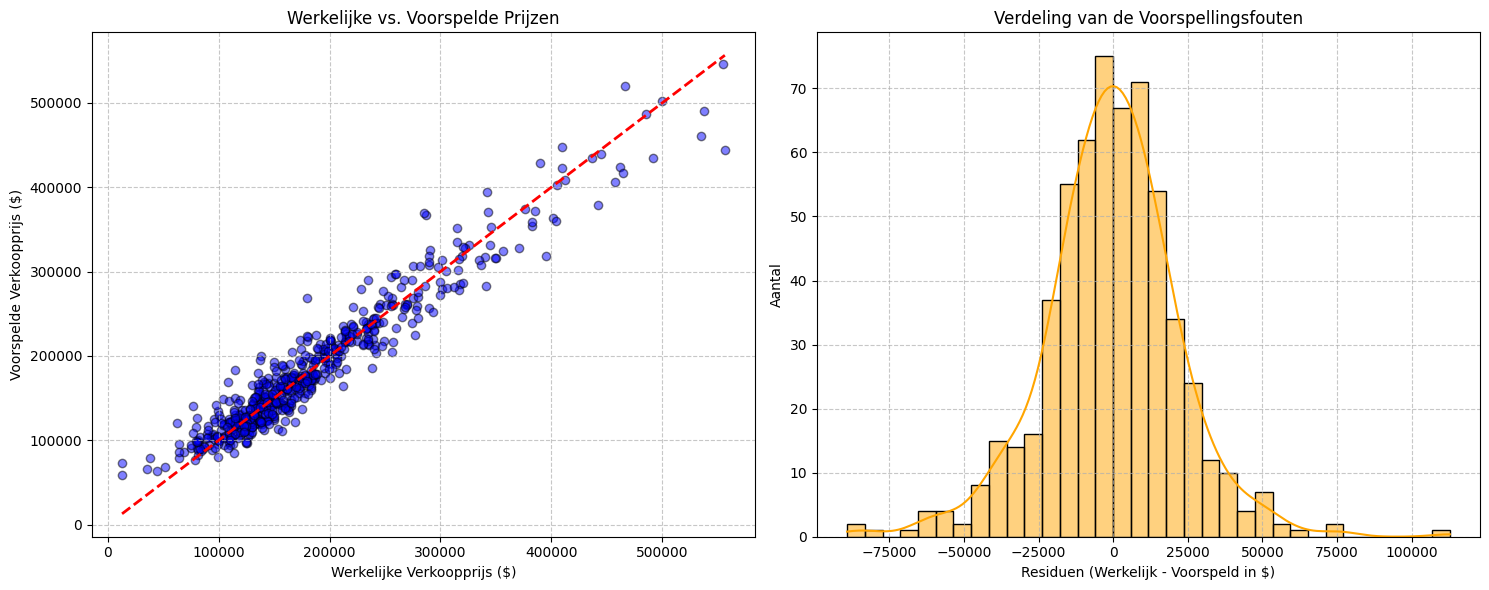

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Grafiek 1: Werkelijke vs Voorspelde prijzen
ax[0].scatter(y_test_dollars, y_pred_dollars, alpha=0.5, color='blue', edgecolor='k')
# Rode stippellijn
ax[0].plot([y_test_dollars.min(), y_test_dollars.max()],
           [y_test_dollars.min(), y_test_dollars.max()], '--r', linewidth=2)
ax[0].set_xlabel('Werkelijke Verkoopprijs ($)')
ax[0].set_ylabel('Voorspelde Verkoopprijs ($)')
ax[0].set_title('Werkelijke vs. Voorspelde Prijzen')
ax[0].grid(True, linestyle='--', alpha=0.7)

# Grafiek 2: Distributie van de residuen
residuals = y_test_dollars - y_pred_dollars
sns.histplot(residuals, kde=True, ax=ax[1], color='orange')
ax[1].set_xlabel('Residuen (Werkelijk - Voorspeld in $)')
ax[1].set_ylabel('Aantal')
ax[1].set_title('Verdeling van de Voorspellingsfouten')
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


